We want to reevaluate how boosted trees perform on the aggregated data.

In [1]:
import pandas as pd
df = pd.read_csv("../../data/aggregated_rolling_features.csv")
df.shape

(5539, 97)

Drop arbitrary features

In [2]:
to_drop = []
to_drop.extend([f"team{i}_player{k}_id" for i in range(1,3) for k in range(1,6)])
to_drop.extend([f"team{i}_id" for i in range(1,3)])
to_drop.extend([f"team{i}" for i in range(1,3)])
to_drop.extend(["tournament", "match_id", "game_id", "map_id", "map_name", "datetime", "Unnamed: 0"])
df = df.drop(to_drop, axis=1)
df

,team1_win,bestOf,team1_previous_10_average_map_score,team2_previous_10_average_map_score,previous_10_games_team1_average_kills,previous_10_games_team1_std_kills,previous_10_games_team1_range_kills,previous_10_games_team1_max_kills,previous_10_games_team1_min_kills,previous_10_games_team1_median_kills,...,previous_10_games_team2_range_kast,previous_10_games_team2_max_kast,previous_10_games_team2_min_kast,previous_10_games_team2_median_kast,previous_10_games_team2_average_kddiff,previous_10_games_team2_std_kddiff,previous_10_games_team2_range_kddiff,previous_10_games_team2_max_kddiff,previous_10_games_team2_min_kddiff,previous_10_games_team2_median_kddiff
0,0,3.0,13.000000,13.000000,16.000000,0.000000e+00,0.0,16.000000,16.000000,16.000000,...,0.00,70.000000,70.000000,70.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000
1,1,3.0,12.333333,12.333333,15.600000,4.127953e+00,10.0,22.000000,12.000000,13.000000,...,25.00,83.300000,58.300000,58.300000,-0.600000,3.136877,9.0,4.000000,-5.000000,0.000000
2,1,3.0,11.600000,11.600000,15.100000,2.083267e+00,5.5,18.500000,13.000000,14.000000,...,17.30,75.000000,57.700000,60.100000,-1.600000,5.885576,17.5,8.500000,-9.000000,-1.500000
3,1,3.0,11.571429,11.571429,14.612903,1.776357e-15,0.0,14.612903,14.612903,14.612903,...,0.00,71.535484,71.535484,71.535484,-0.032258,0.000000,0.0,-0.032258,-0.032258,-0.032258
4,1,3.0,10.666667,10.666667,13.600000,4.363485e+00,13.0,21.000000,8.000000,13.000000,...,33.30,60.000000,26.700000,33.300000,-9.000000,2.280351,6.0,-6.000000,-12.000000,-9.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5534,0,3.0,13.400000,9.500000,14.140000,9.200000e-01,2.6,15.400000,12.800000,14.200000,...,6.89,77.400000,70.510000,76.760000,0.780000,2.465279,6.4,3.500000,-2.900000,1.800000
5535,0,3.0,9.700000,11.100000,14.680000,1.175415e+00,3.3,16.600000,13.300000,14.900000,...,6.96,78.300000,71.340000,76.820000,0.920000,2.741095,7.0,3.700000,-3.300000,2.300000
5536,1,3.0,11.000000,10.700000,14.440000,6.590903e-01,1.7,15.400000,13.700000,14.600000,...,6.96,79.800000,72.840000,75.820000,1.140000,2.793278,7.1,3.900000,-3.200000,2.700000
5537,0,5.0,11.400000,12.700000,14.780000,2.594147e+00,6.8,17.500000,10.700000,14.900000,...,5.71,83.730000,78.020000,82.000000,4.280000,3.398470,8.7,7.800000,-0.900000,5.200000


Create train/test split

In [3]:
import math
X = df.drop("team1_win", axis=1)
y = df.team1_win
split_point = math.ceil(len(df) * 0.8)
X_train = X[:split_point]
X_test = X[split_point:]
y_train = y[:split_point]
y_test = y[split_point:]

Now we do a grid search for the optimal learning rate, depth, and number of estimators

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import numpy as np
param_grid = {"learning_rate": np.arange(0.1, 1.1, 0.1), "n_estimators": np.arange(1, 252, 50), "max_depth": np.arange(1, 5, 1)}
gbc = GradientBoostingClassifier(random_state=42)
cv = GridSearchCV(gbc, param_grid=param_grid, cv=TimeSeriesSplit(), n_jobs=-1, verbose=2)
cv.fit(X_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.1, 0....8, 0.9, 1. ]), 'max_depth': array([1, 2, 3, 4]), 'n_estimators': array([ 1, ...51, 201, 251])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

Let's examime the best params

In [15]:
cv.best_params_

{'learning_rate': np.float64(0.1),
 'max_depth': np.int64(1),
 'n_estimators': np.int64(101)}

Let's see the score

In [16]:
cv.best_score_

np.float64(0.5655826558265582)

Let's also look at a 3D heatmap to see if there are any trends (ChatGPT generated)

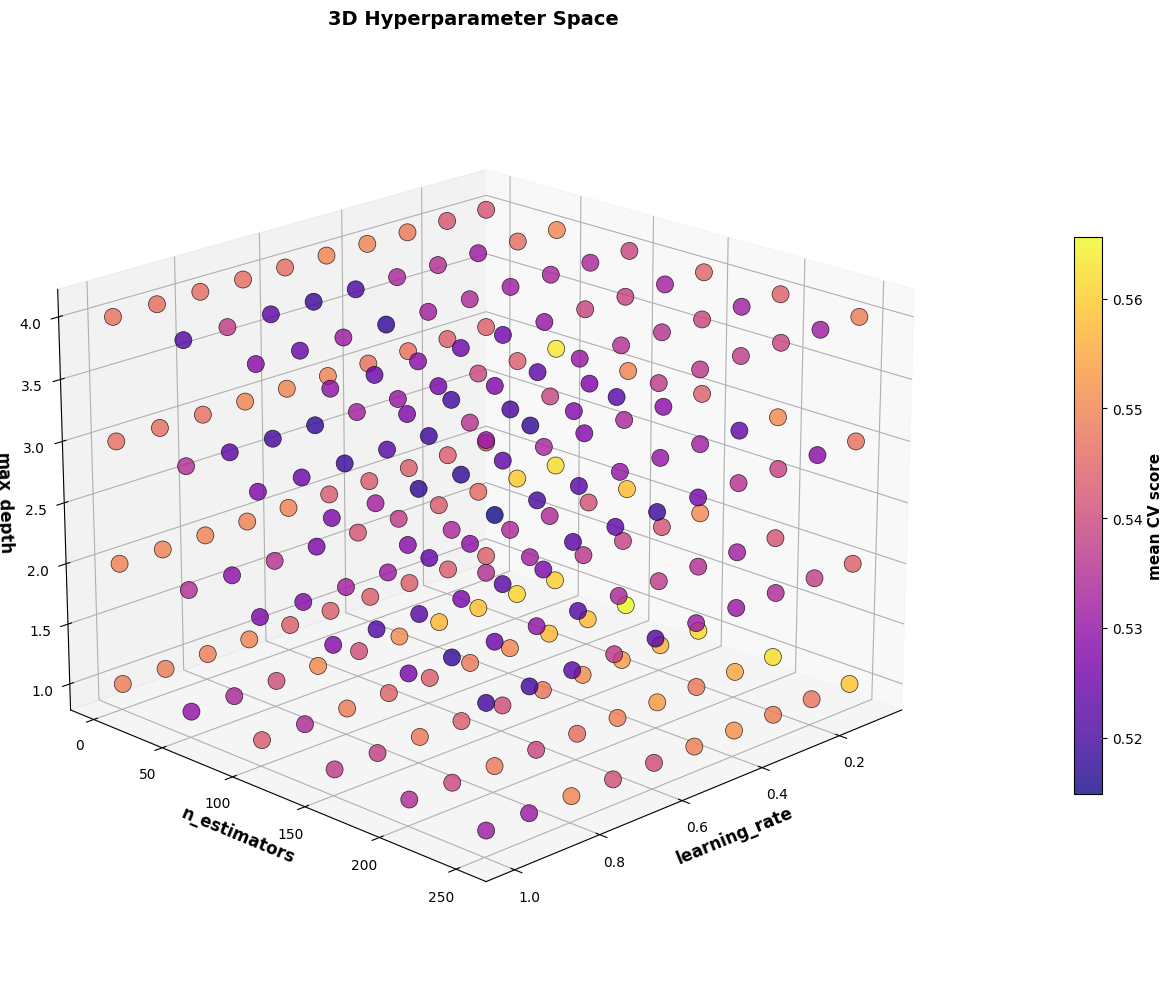

In [19]:
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt

# Extract results into a dataframe for easier access
results_df = pd.DataFrame(cv.cv_results_)

# Get the parameters and scores
learning_rates = results_df['param_learning_rate'].values
n_estimators = results_df['param_n_estimators'].values
max_depths = results_df['param_max_depth'].values
scores = results_df['mean_test_score'].values

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Create scatter plot with color representing mean_test_score
scatter = ax.scatter(learning_rates, n_estimators, max_depths, 
                     c=scores, cmap=cm.plasma, s=150, alpha=0.8, edgecolors='black', linewidth=0.5)

# Set labels with larger font
ax.set_xlabel("learning_rate", fontsize=12, fontweight='bold')
ax.set_ylabel("n_estimators", fontsize=12, fontweight='bold')
ax.set_zlabel("max_depth", fontsize=12, fontweight='bold')
ax.set_title("3D Hyperparameter Space", fontsize=14, fontweight='bold', pad=20)

# Improve viewing angle for better visibility
ax.view_init(elev=20, azim=45)

# Add gridlines
ax.grid(True, alpha=0.3)

# Improve colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1, label="mean CV score")
cbar.set_label("mean CV score", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

We can see that as the depth increases, the general trend is that the score of test data also goes down. Given this, we should stay at a max depth of 1. Similarly, as learning rate increases the test score goes down for that number of estimators, with the best scores occuring at low learning rates with estimators in the 50-150 range. So let's do a finer grid search to see if we can eek out any more performance.

In [21]:
param_grid = {"learning_rate": np.arange(0.05, 0.11, 0.01), "n_estimators": np.arange(50, 151, 20), "max_depth": [1]}
cv = GridSearchCV(gbc, param_grid=param_grid, cv=TimeSeriesSplit(), n_jobs=-1, verbose=2)
cv.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.05, ..., 0.09, 0.1 ]), 'max_depth': [1], 'n_estimators': array([ 50, ...10, 130, 150])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

Now examine the score and best params

In [22]:
cv.best_params_

{'learning_rate': np.float64(0.1),
 'max_depth': 1,
 'n_estimators': np.int64(130)}

In [23]:
cv.best_score_

np.float64(0.5655826558265582)

This model performs pretty much the same as the first one.

And one more heatmap, this time 2D (ChatGPT generated)

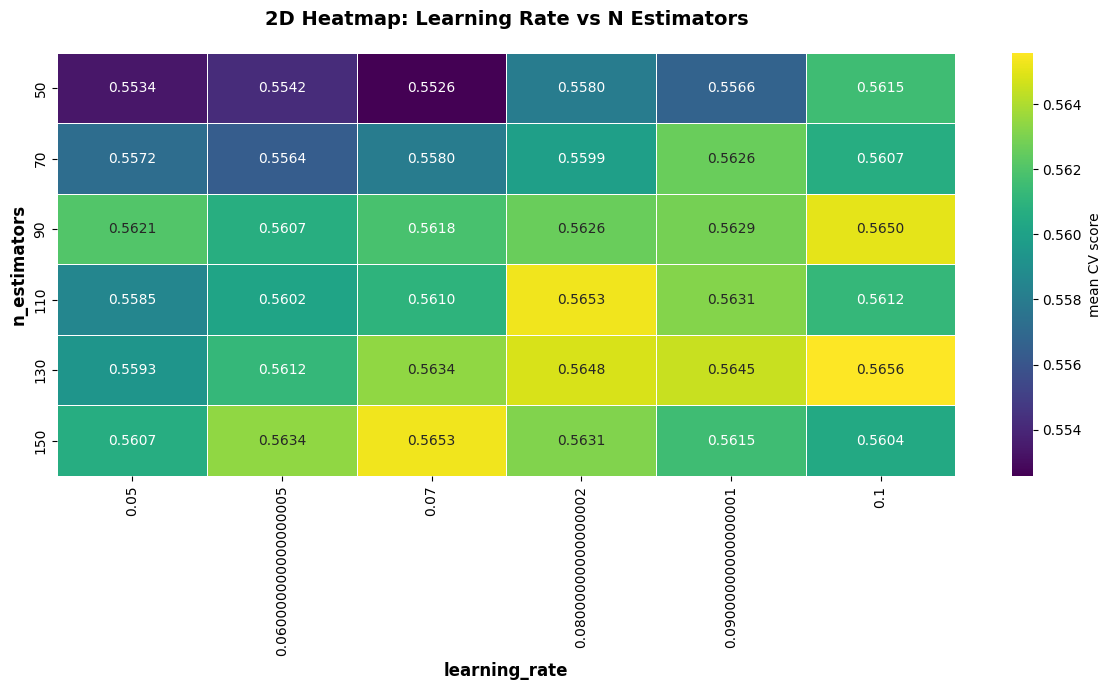

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract results into a dataframe for easier access
results_df = pd.DataFrame(cv.cv_results_)

# Pivot the data to create a 2D grid for heatmap
heatmap_data = results_df.pivot_table(
    values='mean_test_score',
    index='param_n_estimators',
    columns='param_learning_rate',
    aggfunc='mean'
)

# Create the heatmap
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.4f', 
            cmap='viridis', 
            cbar_kws={'label': 'mean CV score'},
            linewidths=0.5,
            linecolor='white',
            ax=ax)

ax.set_xlabel('learning_rate', fontsize=12, fontweight='bold')
ax.set_ylabel('n_estimators', fontsize=12, fontweight='bold')
ax.set_title('2D Heatmap: Learning Rate vs N Estimators', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

We see that at generally 110-150 estimators do the best with most at 130, and learning rates from 0.07 to 0.1 do the best, spiking at 0.1.

Now, let's gauge the models performance on the test set.

Let's see what the feature importance of the gradient boosted tree is (have ChatGPT plot it)

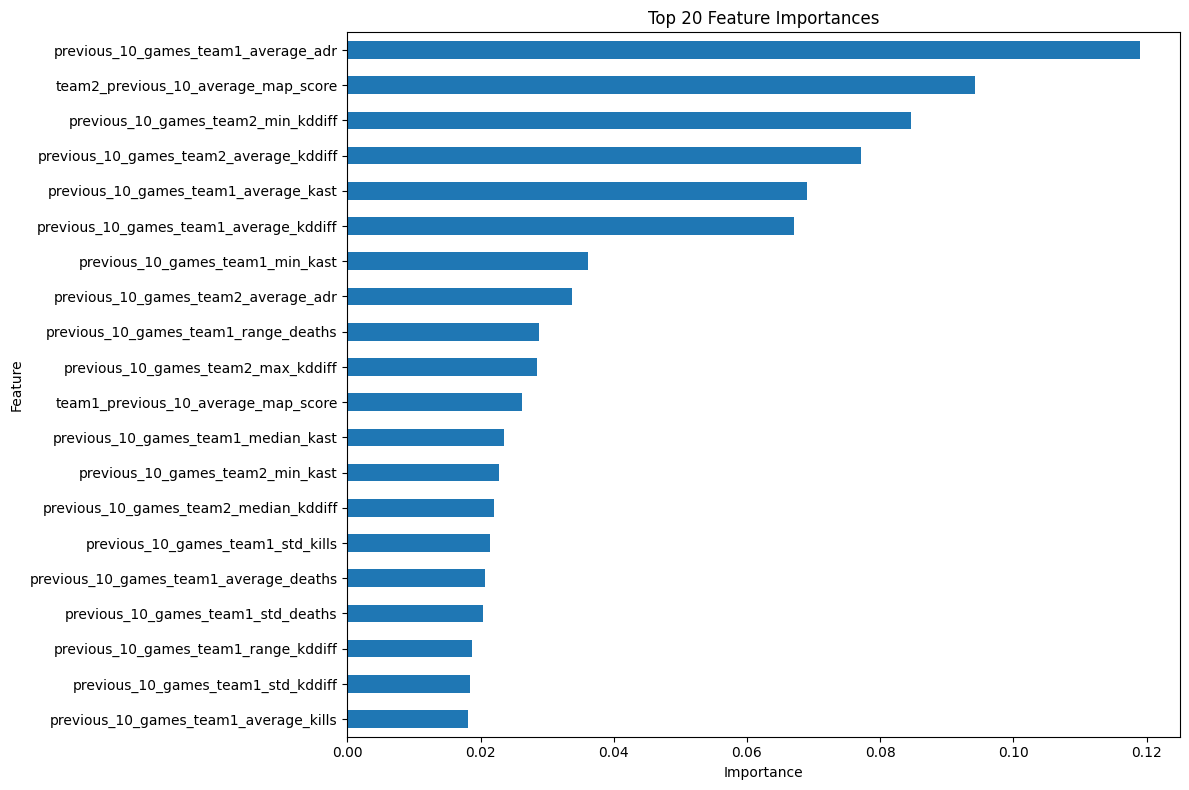

previous_10_games_team1_average_adr       0.119077
team2_previous_10_average_map_score       0.094243
previous_10_games_team2_min_kddiff        0.084625
previous_10_games_team2_average_kddiff    0.077112
previous_10_games_team1_average_kast      0.068997
                                            ...   
previous_10_games_team2_average_kast      0.000000
previous_10_games_team2_range_adr         0.000000
previous_10_games_team2_max_adr           0.000000
previous_10_games_team2_std_kast          0.000000
previous_10_games_team2_range_kddiff      0.000000
Length: 75, dtype: float64

In [29]:
feature_importance = pd.Series(
    cv.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
feature_importance.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

feature_importance

It appears our model is taking mostly 6 features into account mainly with a steep drop off afterwards. These are: team 1 average adr, team 2 average map score, team 2 min kddiff, team 2 average kddiff, team 1 average kast, and team 1 average kddiff. Why exactly the model considers the team 2 stat over team 1, I am not sure. I wonder if this is further ordering-based noise that could be reduced.

In [ ]:
cv.best_estimator_.score(X_test, y_test)

0.5672990063233966

It does roughly 1% better than baseline. It does better than the player based tree though with a 0.006 improvement with feature importances that are more interpretable, other than why team 1 stat should matter more than team 2 stat (perhaps more ordering invariance issues).

Finally, we'll have a look at the confusion matrix (have ChatGPT plot)

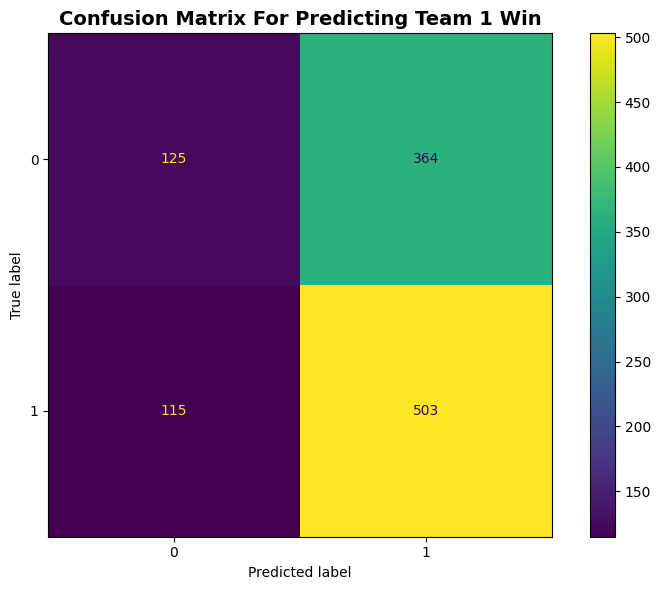

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, cv.best_estimator_.predict(X_test))).plot(ax=ax)
plt.title("Confusion Matrix For Predicting Team 1 Win", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

It looks like the model more often struggles with classifying losses for team 1 with majority of lose cases being wrongly predicted.